<a href="https://colab.research.google.com/github/ErickAlcaino/MAT281--Aplicaciones-de-la-Matem-tica/blob/main/Tarea2/T2AplicaErickAlcaino.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.arima.model import ARIMA
from sklearn.model_selection import TimeSeriesSplit
from sklearn.metrics import mean_squared_error
from statsmodels.tsa.holtwinters import ExponentialSmoothing
from pylab import rcParams
import statsmodels.api as sm
from astropy.timeseries import LombScargle


In [3]:
def datainfo(data):
    temp_ps = pd.DataFrame(index=data.columns)
    temp_ps['DataType'] = data.dtypes
    temp_ps["Non-null_Values"] = data.count()
    temp_ps['Unique_Values'] = data.nunique()
    temp_ps['NaN_Values'] = data.isnull().sum()
    temp_ps['NaN_Values_Percentage'] = (temp_ps['NaN_Values']/len(data))*100
    return temp_ps



In [4]:
# Cargar los datos
data = pd.read_csv('drive/MyDrive/Data/wind_data.txt', delim_whitespace=True)
kil_data = data['KIL']
date_range = pd.date_range(start='1961-01-01', periods=len(kil_data), freq='D')
kil_data.index = date_range



display(datainfo(data))

<ipython-input-4-4a64bcb61001>:2: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
  data = pd.read_csv('drive/MyDrive/Data/wind_data.txt', delim_whitespace=True)


,DataType,Non-null_Values,Unique_Values,NaN_Values,NaN_Values_Percentage
year,int64,6574,18,0,0.0
month,int64,6574,12,0,0.0
day,int64,6574,31,0,0.0
RPT,float64,6574,671,0,0.0
VAL,float64,6574,607,0,0.0
ROS,float64,6574,611,0,0.0
KIL,float64,6574,450,0,0.0
SHA,float64,6574,596,0,0.0
BIR,float64,6574,461,0,0.0
DUB,float64,6574,580,0,0.0


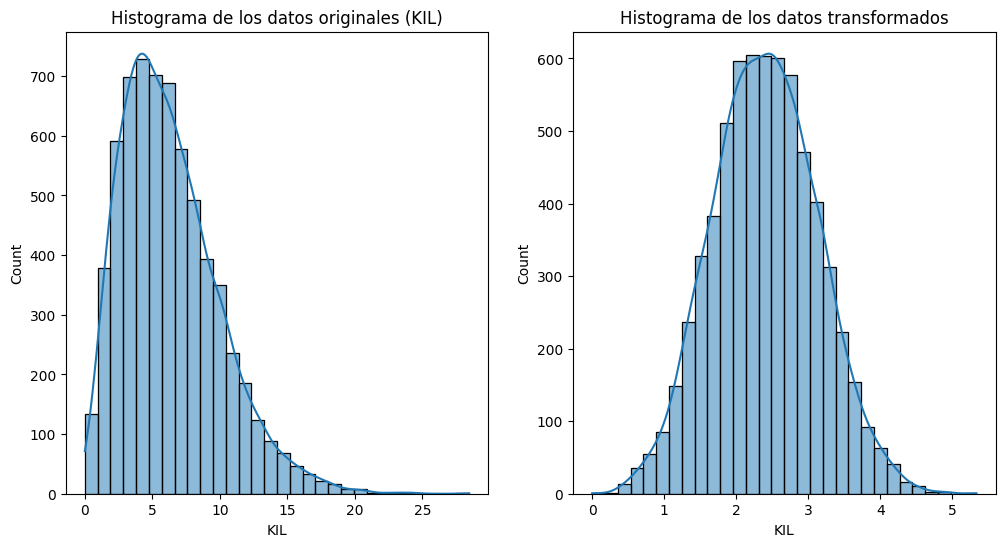

In [5]:
# a. Transformación de la serie temporal aplicando la raíz cuadrada
kil_transformado = np.sqrt(kil_data)

# Comparación de histogramas
plt.figure(figsize=(12, 6))

plt.subplot(1, 2, 1)
sns.histplot(kil_data, bins=30, kde=True)
plt.title('Histograma de los datos originales (KIL)')

plt.subplot(1, 2, 2)
sns.histplot(kil_transformado, bins=30, kde=True)
plt.title('Histograma de los datos transformados')

plt.show()

<ipython-input-34-76a83bb2a864>:12: FutureWarning: 'Y' is deprecated and will be removed in a future version, please use 'YE' instead.
  date_range = pd.date_range(start='1961', periods=18, freq='Y')


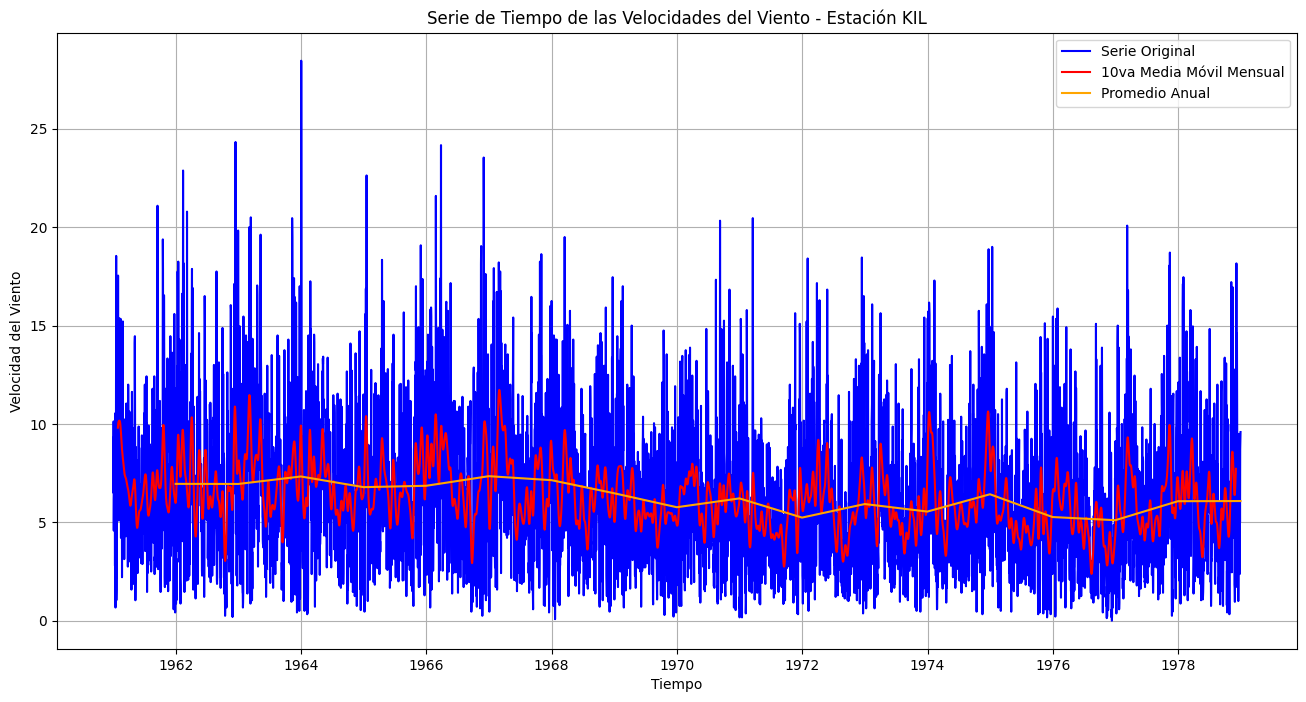

In [34]:
PromedioAnual=[]
for i in range(1961,1979):
  PromedioAnual.append(kil_data[str(i)+'-01-01':str(i)+'-12-31'].mean())

media_movil = kil_data.rolling(window=7, center=True).mean()
# Segunda aplicación de la media móvil
for i in range(1,9):
  media_movil = media_movil.rolling(window=7, center=True).mean()

# Convert PromedioAnual to a pandas Series and then assign the index
PromedioAnual = pd.Series(PromedioAnual)  # Convert to Series first
date_range = pd.date_range(start='1961', periods=18, freq='Y')
PromedioAnual.index = date_range

plt.figure(figsize=(16, 8))
plt.plot(kil_data, label='Serie Original', color='blue')
plt.plot(media_movil, label='10va Media Móvil Mensual', color='red')
plt.plot(PromedioAnual, label='Promedio Anual', color='orange')
plt.title('Serie de Tiempo de las Velocidades del Viento - Estación KIL')
plt.xlabel('Tiempo')
plt.ylabel('Velocidad del Viento')
plt.legend()
plt.grid(True)
plt.show()




<ipython-input-36-75e16844b053>:12: FutureWarning: 'Y' is deprecated and will be removed in a future version, please use 'YE' instead.
  date_range = pd.date_range(start='1961', periods=18, freq='Y')


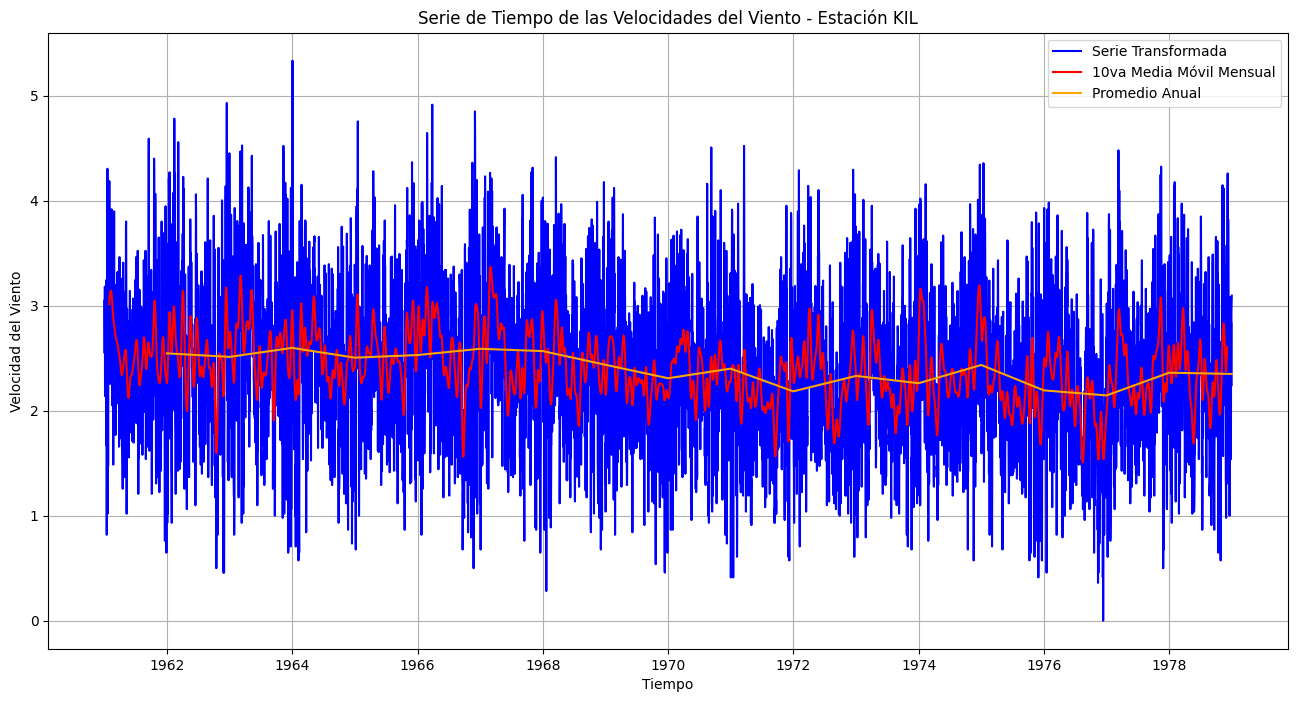

In [36]:
PromedioAnual=[]
for i in range(1961,1979):
  PromedioAnual.append(kil_transformado[str(i)+'-01-01':str(i)+'-12-31'].mean())

media_movil = kil_transformado.rolling(window=7, center=True).mean()
# Segunda aplicación de la media móvil
for i in range(1,9):
  media_movil = media_movil.rolling(window=7, center=True).mean()

# Convert PromedioAnual to a pandas Series and then assign the index
PromedioAnual = pd.Series(PromedioAnual)  # Convert to Series first
date_range = pd.date_range(start='1961', periods=18, freq='Y')
PromedioAnual.index = date_range

plt.figure(figsize=(16, 8))
plt.plot(kil_transformado, label='Serie Transformada', color='blue')
plt.plot(media_movil, label='10va Media Móvil Mensual', color='red')
plt.plot(PromedioAnual, label='Promedio Anual', color='orange')
plt.title('Serie de Tiempo de las Velocidades del Viento - Estación KIL')
plt.xlabel('Tiempo')
plt.ylabel('Velocidad del Viento')
plt.legend()
plt.grid(True)
plt.show()

In [43]:
print('El promedio es:', kil_transformado.mean())
kil_residuos = kil_transformado - kil_transformado.mean()

El promedio es: 2.4042147171727914


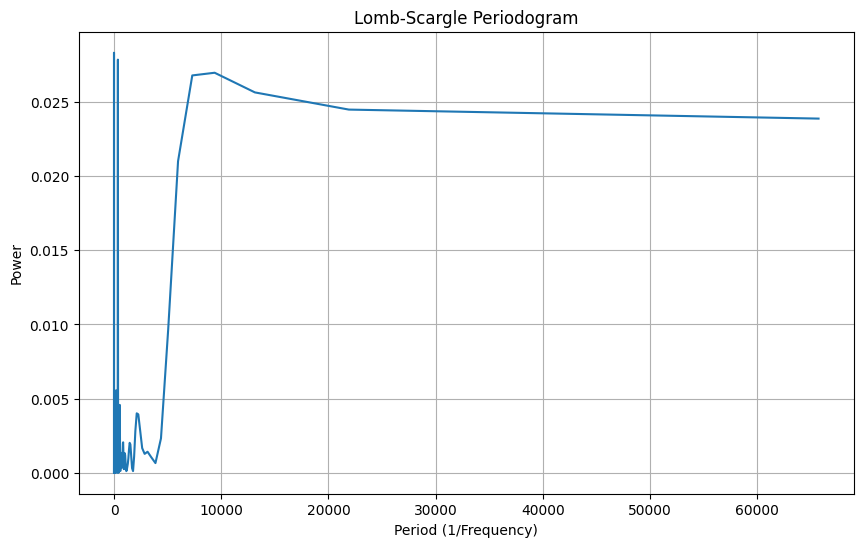

El periodo dominante es: 0.5006893714912514


In [38]:

time = np.arange(len(kil_residuos))

valid_indices = np.isfinite(kil_residuos)
time = time[valid_indices]
serie = kil_residuos[valid_indices]


frequency, power = LombScargle(time, serie).autopower()


plt.figure(figsize=(10, 6))
plt.plot(1/frequency, power)
plt.title('Lomb-Scargle Periodogram')
plt.xlabel('Period (1/Frequency)')
plt.ylabel('Power')
plt.grid(True)
plt.show()

# Encontrar el periodo dominante
dominant_period = 1 / frequency[np.argmax(power)]
print(f"El periodo dominante es: {dominant_period}")

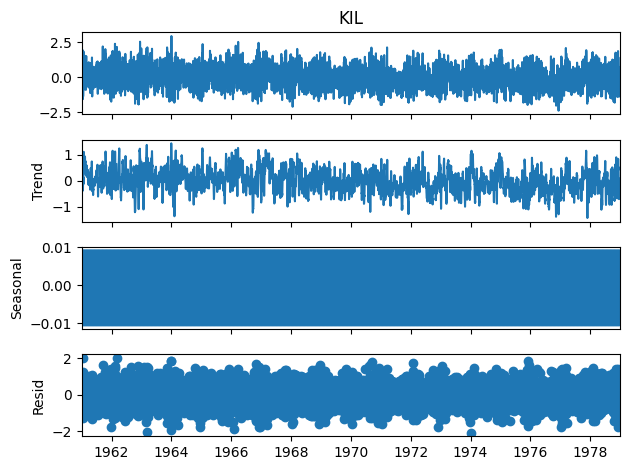

In [39]:
descomposicion = sm.tsa.seasonal_decompose(kil_residuos, model='additive')

descomposicion.plot()
plt.show()

<ipython-input-49-de56d9b8a0ba>:18: FutureWarning: 'Y' is deprecated and will be removed in a future version, please use 'YE' instead.
  date_range = pd.date_range(start='1961', periods=18, freq='Y')


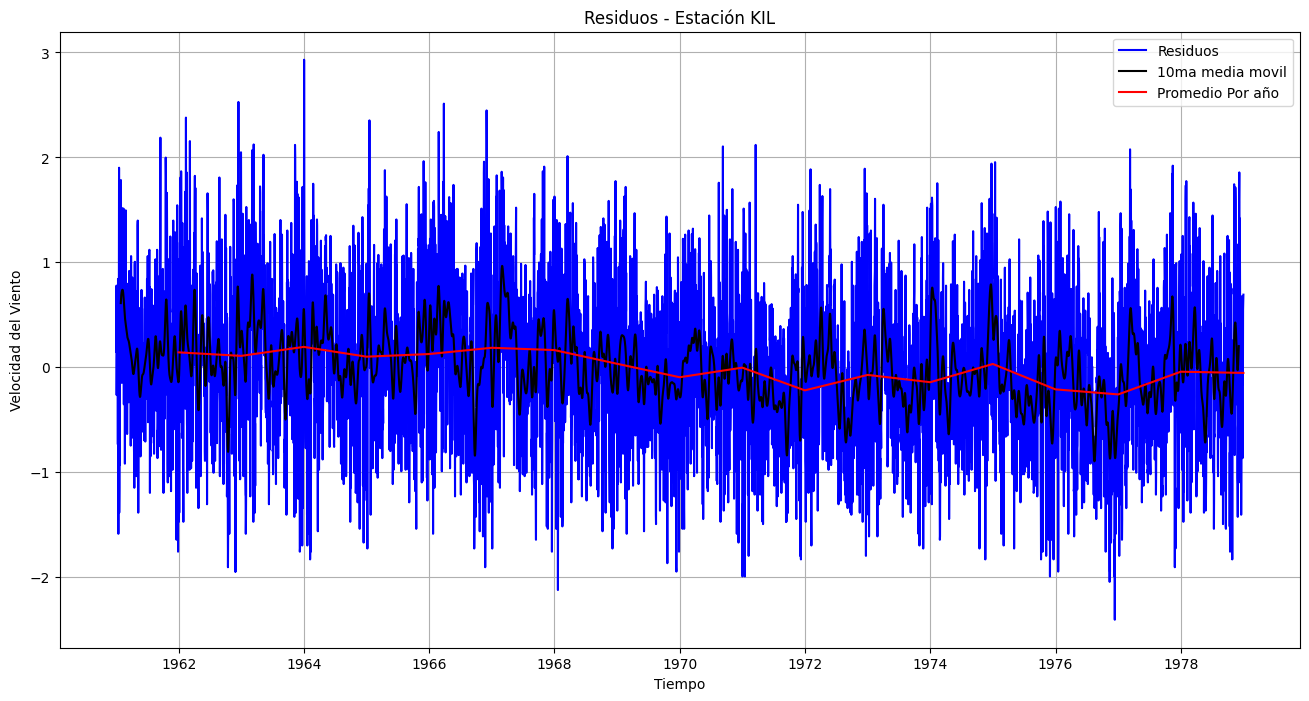

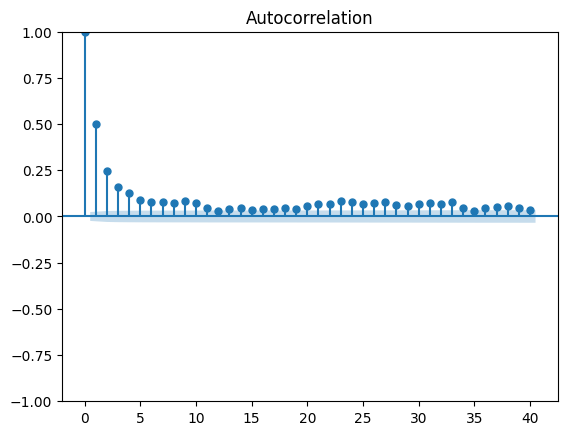

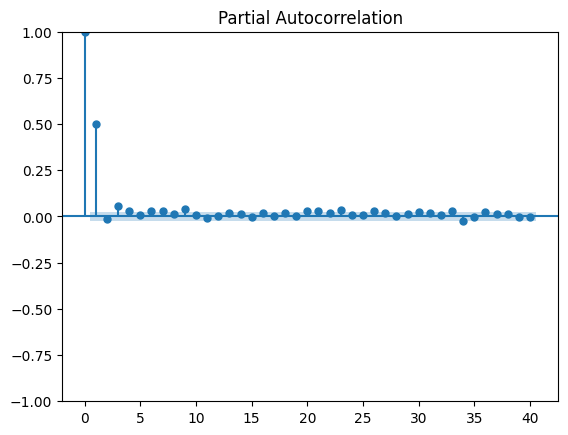

In [49]:
# b. Eliminación de la tendencia
# Restamos el promedio

#kil_residuos = kil_residuos.diff(365).dropna()

media_movil = kil_residuos.rolling(window=7, center=True).mean()
# Segunda aplicación de la media móvil
for i in range(1,9):
  media_movil = media_movil.rolling(window=7, center=True).mean()


PromedioAnual=[]
for i in range(1961,1979):
  PromedioAnual.append(kil_residuos[str(i)+'-01-01':str(i)+'-12-31'].mean())

# Convert PromedioAnual to a pandas Series and then assign the index
PromedioAnual = pd.Series(PromedioAnual)  # Convert to Series first
date_range = pd.date_range(start='1961', periods=18, freq='Y')
PromedioAnual.index = date_range

plt.figure(figsize=(16, 8))
plt.plot(kil_residuos, color='blue', label='Residuos')
plt.plot(media_movil, color='black',label='10ma media movil')
plt.plot(PromedioAnual, color='red',label='Promedio Por año')
plt.title('Residuos - Estación KIL')
plt.xlabel('Tiempo')
plt.ylabel('Velocidad del Viento')
plt.grid(True)
plt.legend()
plt.show()

plot_acf(kil_residuos, lags=40)
plt.show()


plot_pacf(kil_residuos, lags=40)
plt.show()

In [67]:


print(f"Media: {kil_residuos.mean()}")
print(f"Varianza: {kil_residuos.var()}")

Media: 2.5940105960210534e-17
Varianza: 0.5261063406632293


In [10]:
from statsmodels.tsa.stattools import adfuller

#test Dickey-Fulle:
print ('Resultados del test de Dickey-Fuller:')
dftest = adfuller(kil_residuos, autolag='AIC')
dfoutput = pd.Series(dftest[0:4],
                     index=['Test Statistic','p-value','#Lags Used','Number of Observations Used'])

print(dfoutput)



Resultados del test de Dickey-Fuller:
Test Statistic                -1.232257e+01
p-value                        6.699608e-23
#Lags Used                     3.300000e+01
Number of Observations Used    6.175000e+03
dtype: float64


In [68]:
# d. Ajuste de un modelo ARMA a los residuos
model = ARIMA(kil_residuos.dropna(), order=(1, 0, 2))
arma_result = model.fit()

print(arma_result.summary())



                               SARIMAX Results                                
Dep. Variable:                    KIL   No. Observations:                 6574
Model:                 ARIMA(1, 0, 3)   Log Likelihood               -6235.434
Date:                Mon, 14 Oct 2024   AIC                          12482.867
Time:                        05:33:30   BIC                          12523.613
Sample:                    01-01-1961   HQIC                         12496.952
                         - 12-31-1978                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.0012      0.031      0.038      0.970      -0.059       0.062
ar.L1          0.9791      0.006    166.554      0.000       0.968       0.991
ma.L1         -0.4833      0.013    -36.375      0.0

**L jung Box mayor a 0.05, por lo que 'q' es bueno.**


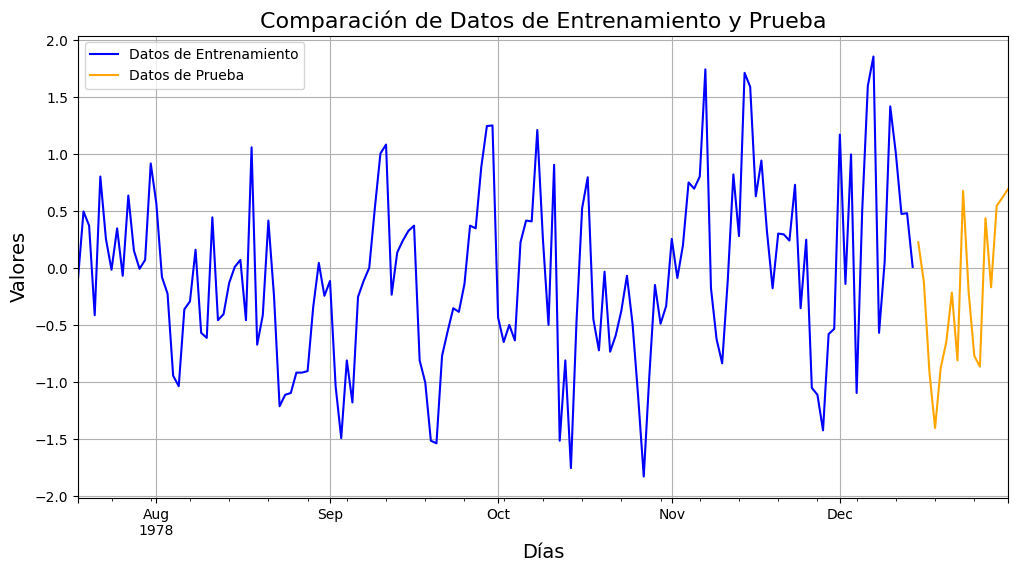

In [90]:
target_date =  "1978-12-15"
# crear conjunto de entrenamiento y de testeo


mask_ds_original= kil_data.index < target_date
mask_ds = kil_residuos.index < target_date


y_train = kil_residuos[mask_ds]
y_test = kil_residuos[~mask_ds]


plt.figure(figsize=(12, 6))
y_train[-150:].plot(label='Datos de Entrenamiento', color='blue')  # Etiqueta para los datos de entrenamiento
y_test.plot(label='Datos de Prueba', color='orange')  # Etiqueta para los datos de prueba

# Agregar etiquetas y título
plt.xlabel('Días', fontsize=14)
plt.ylabel('Valores', fontsize=14)
plt.title('Comparación de Datos de Entrenamiento y Prueba', fontsize=16)
plt.legend()  # Muestra la leyenda con las etiquetas
plt.grid(True)  # Opcional: agrega una cuadrícula para facilitar la visualización

plt.show()


In [80]:
model = ARIMA(y_train, order=(1, 0,3))
model_fit = model.fit()

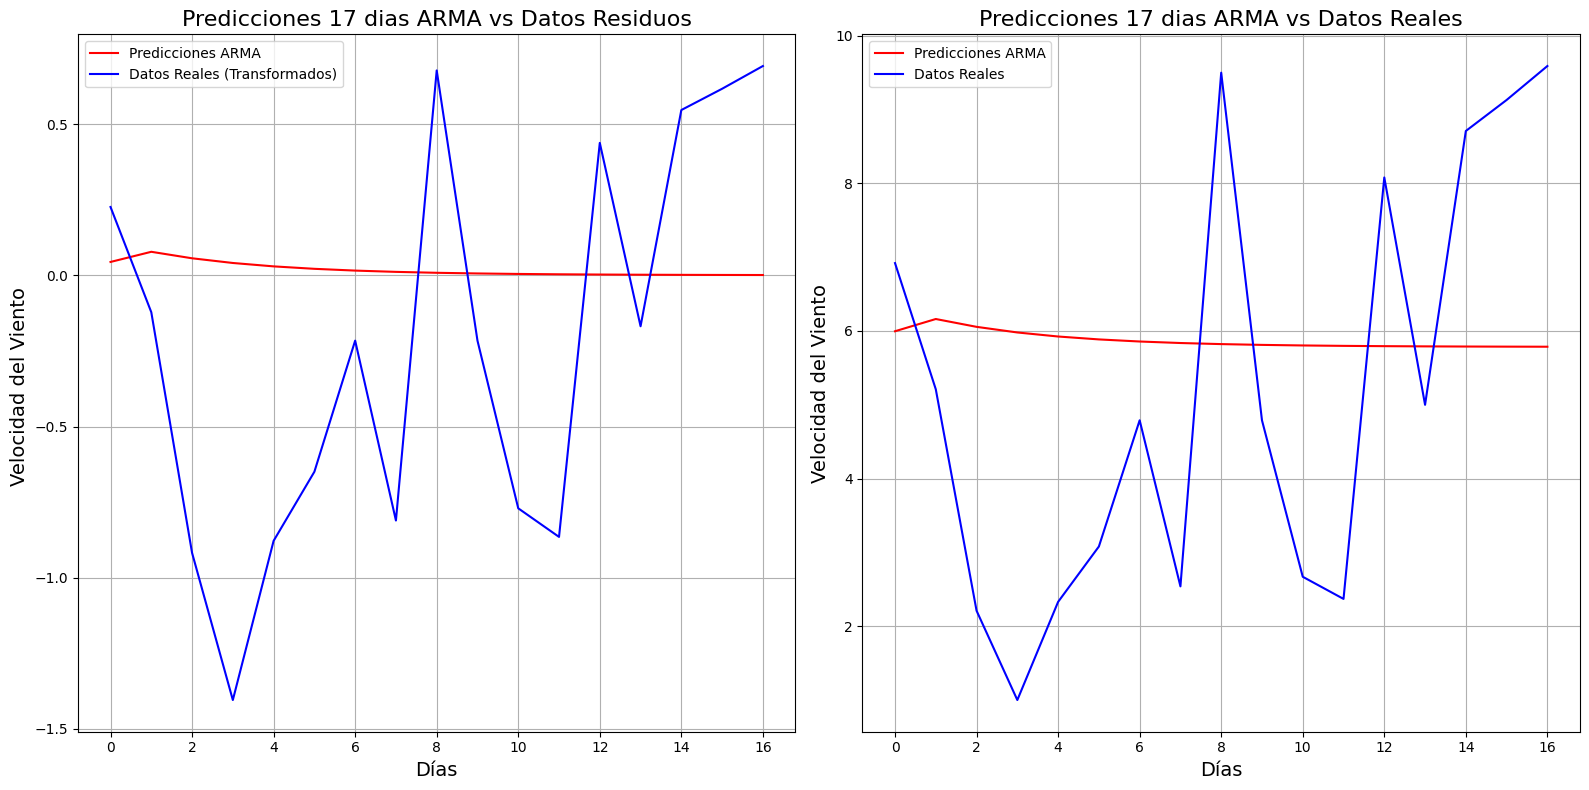

In [81]:
predictions_residuals = model_fit.forecast(steps=17)
predictions_residuals_untransformed = np.power((predictions_residuals + kil_transformado.mean()),2)

# Crear subplots
fig, axs = plt.subplots(1, 2, figsize=(16, 8))  # 1 fila y 2 columnas

# Primer gráfico: Predicciones ARMA vs Datos Reales (Transformados)
axs[0].plot(predictions_residuals.values, color='red', label='Predicciones ARMA')
axs[0].plot(y_test.reset_index(drop=True), color='blue', label='Datos Reales (Transformados)')
axs[0].set_title('Predicciones 17 dias ARMA vs Datos Residuos', fontsize=16)
axs[0].set_xlabel('Días', fontsize=14)
axs[0].set_ylabel('Velocidad del Viento ', fontsize=14)
axs[0].legend()
axs[0].grid(True)

# Segundo gráfico: Predicciones ARMA vs Datos Reales (Originales)
axs[1].plot(predictions_residuals_untransformed.values, color='red', label='Predicciones ARMA')
axs[1].plot(kil_data[-17:].reset_index(drop=True), color='blue', label='Datos Reales')
axs[1].set_title('Predicciones 17 dias ARMA vs Datos Reales', fontsize=16)
axs[1].set_xlabel('Días', fontsize=14)
axs[1].set_ylabel('Velocidad del Viento', fontsize=14)
axs[1].legend()
axs[1].grid(True)

# Ajustar el layout para evitar superposición
plt.tight_layout()
plt.show()

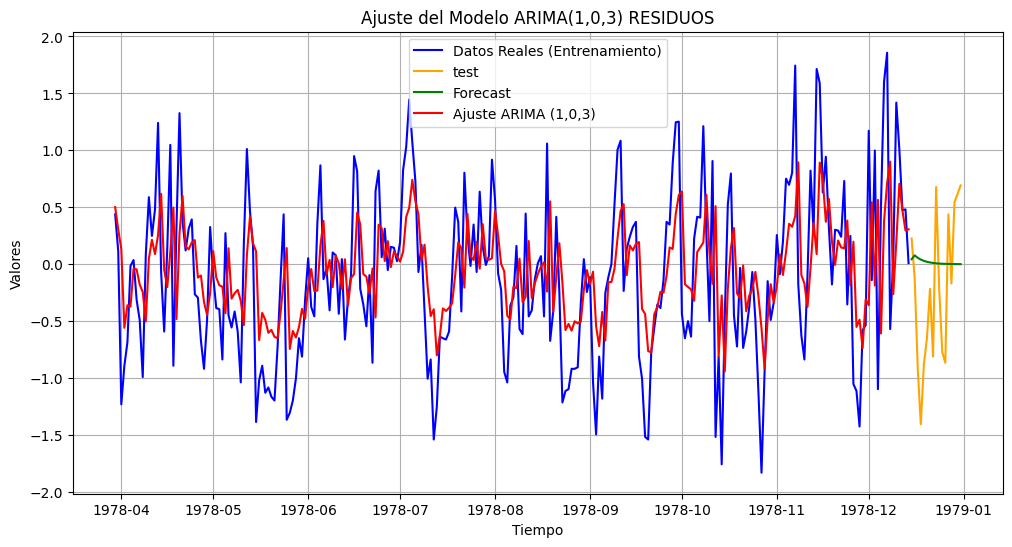

In [84]:
ajuste = model_fit.fittedvalues  # Esto devuelve las predicciones dentro de la muestra

# Graficar los datos reales y las predicciones
plt.figure(figsize=(12, 6))
plt.plot(y_train[-260:], label='Datos Reales (Entrenamiento)', color='blue')
plt.plot(y_test, label='test', color='orange')
plt.plot(model_fit.forecast(steps=17), label='Forecast', color='green')
plt.plot(ajuste[-260:], label='Ajuste ARIMA (1,0,3) ', color='red')
plt.title('Ajuste del Modelo ARIMA(1,0,3) RESIDUOS')
plt.xlabel('Tiempo')
plt.ylabel('Valores')
plt.legend()
plt.grid(True)
plt.show()

In [91]:
# e. Validación cruzada
tscv = TimeSeriesSplit(n_splits=60)
errors = []

for train_index, test_index in tscv.split(kil_residuos.dropna()):
    train, test = kil_residuos.iloc[train_index], kil_residuos.iloc[test_index]
    model = ARIMA(train, order=(1, 0, 3))
    model_fit = model.fit()
    predictions = model_fit.forecast(steps=len(test))
    error = mean_squared_error(test, predictions)
    errors.append(error)

print('MSE de validación cruzada:', np.mean(errors))



MSE de validación cruzada: 0.5242455314802706
